# Part III: Language Tasks - Sarcasm Detection


## Setup: Imports and Configuration

In [1]:
!pip install contractions wordcloud gensim --quiet

import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contractions
import nltk
from collections import Counter
from wordcloud import WordCloud

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU available: {len(gpus)} device(s)")
else:
    print("No GPU available, using CPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.9 MB/s eta 0:00:00
TensorFlow: 2.20.0
Keras: 3.13.2
No GPU available, using CPU


## Section 1: Data Understanding and Preprocessing

### Load and Explore Dataset

In [2]:
df = pd.read_csv('sarcastic_headlines.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (28619, 2)

First few rows:


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


Class distribution:
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64

Not Sarcastic (0): 14985 (52.4%)
Sarcastic (1): 13634 (47.6%)


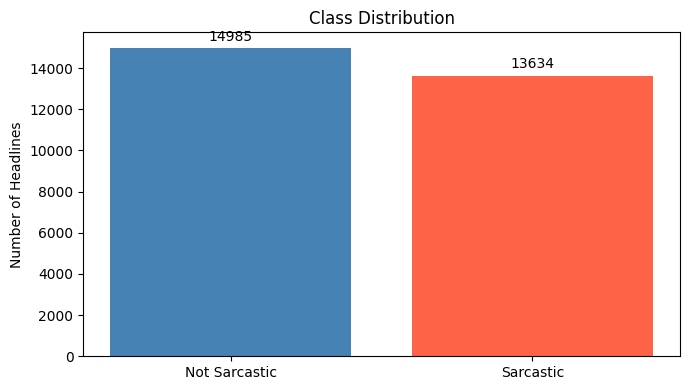

In [3]:
print("Class distribution:")
print(df['is_sarcastic'].value_counts())
print(f"\nNot Sarcastic (0): {(df['is_sarcastic']==0).sum()} ({(df['is_sarcastic']==0).sum()/len(df)*100:.1f}%)")
print(f"Sarcastic (1): {(df['is_sarcastic']==1).sum()} ({(df['is_sarcastic']==1).sum()/len(df)*100:.1f}%)")

counts = df['is_sarcastic'].value_counts()
plt.figure(figsize=(7, 4))
bars = plt.bar(['Not Sarcastic', 'Sarcastic'], [counts[0], counts[1]], color=['steelblue', 'tomato'])
plt.bar_label(bars, padding=3)
plt.title('Class Distribution')
plt.ylabel('Number of Headlines')
plt.tight_layout()
plt.show()

### Text Cleaning and Preprocessing

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]

    return ' '.join(tokens)

df['cleaned'] = df['headline'].apply(clean_text)

print("Text cleaning completed")
print("\nExamples:")
for i in range(3):
    print(f"\nOriginal: {df['headline'].iloc[i]}")
    print(f"Cleaned:  {df['cleaned'].iloc[i]}")

Text cleaning completed

Examples:

Original: thirtysomething scientists unveil doomsday clock of hair loss
Cleaned:  thirtysomething scientist unveil doomsday clock hair loss

Original: dem rep. totally nails why congress is falling short on gender, racial equality
Cleaned:  dem rep totally nail congress falling short gender racial equality

Original: eat your veggies: 9 deliciously different recipes
Cleaned:  eat veggie deliciously different recipe


### Visualize Cleaned Data

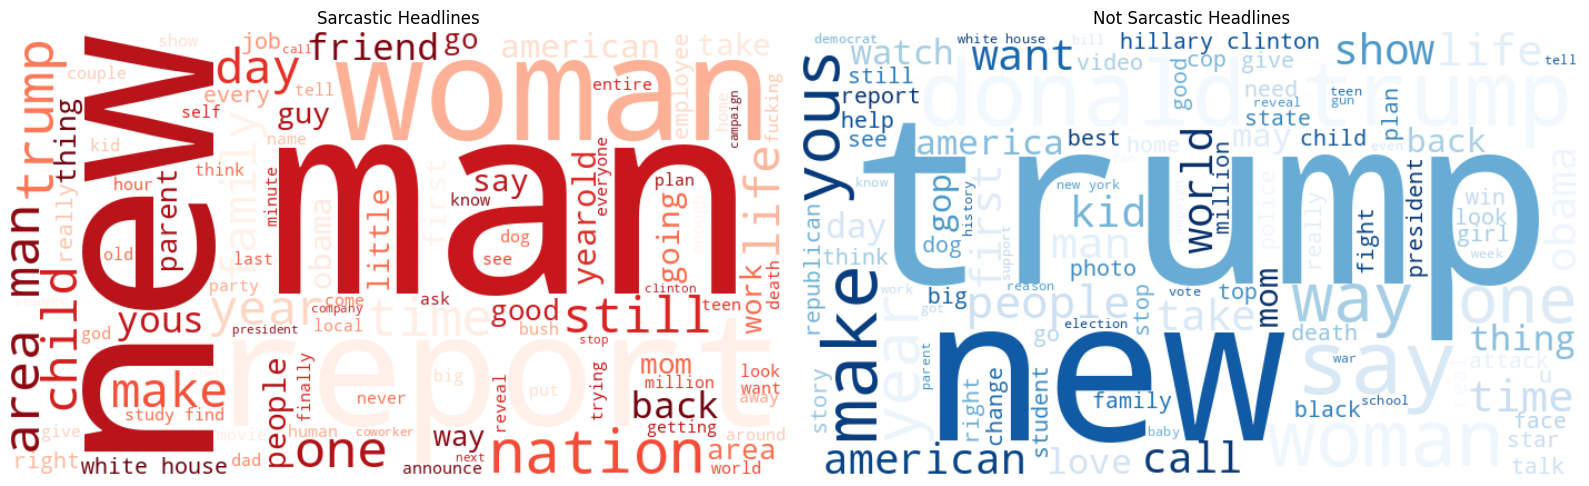

In [5]:
sarc_text = ' '.join(df[df['is_sarcastic'] == 1]['cleaned'])
not_sarc_text = ' '.join(df[df['is_sarcastic'] == 0]['cleaned'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_sarc = WordCloud(width=700, height=400, background_color='white', colormap='Reds', max_words=100).generate(sarc_text)
axes[0].imshow(wc_sarc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Sarcastic Headlines')

wc_not = WordCloud(width=700, height=400, background_color='white', colormap='Blues', max_words=100).generate(not_sarc_text)
axes[1].imshow(wc_not, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Not Sarcastic Headlines')

plt.tight_layout()
plt.show()

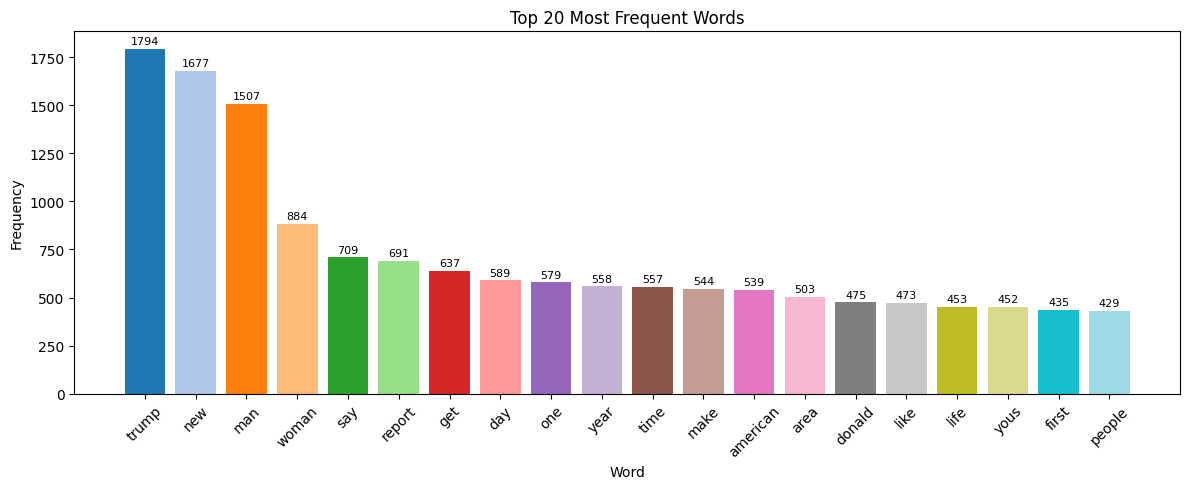

In [6]:
all_words = ' '.join(df['cleaned']).split()
word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)

plt.figure(figsize=(12, 5))
bars = plt.bar(words, freqs, color=plt.cm.tab20.colors[:20])
plt.bar_label(bars, padding=2, fontsize=8)
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Train/Test Split and Tokenization

In [7]:
X = df['cleaned'].values
y = df['is_sarcastic'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Train size: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test size:  {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nClass distribution:")
print(f"Train - Sarcastic: {y_train.sum()}/{len(y_train)} ({y_train.mean()*100:.1f}%)")
print(f"Test  - Sarcastic: {y_test.sum()}/{len(y_test)} ({y_test.mean()*100:.1f}%)")

Train size: 22895 (80%)
Test size:  5724 (20%)

Class distribution:
Train - Sarcastic: 10907/22895 (47.6%)
Test  - Sarcastic: 2727/5724 (47.6%)


95th percentile sequence length: 11


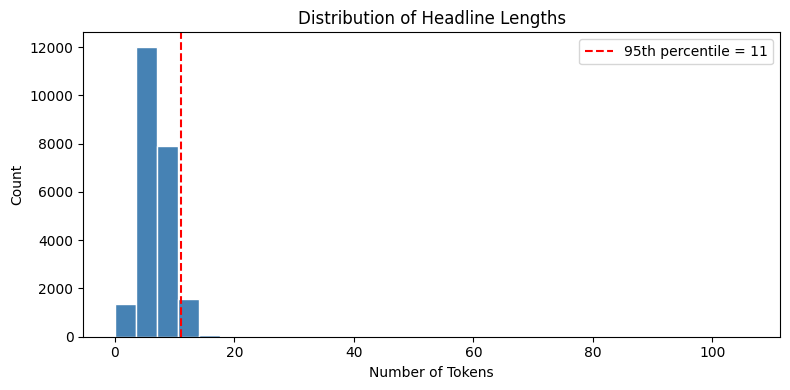

In [8]:
lengths = [len(s.split()) for s in X_train]
MAX_LENGTH = int(np.percentile(lengths, 95))
print(f"95th percentile sequence length: {MAX_LENGTH}")

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=30, color='steelblue', edgecolor='white')
plt.axvline(MAX_LENGTH, color='red', linestyle='--', label=f'95th percentile = {MAX_LENGTH}')
plt.title('Distribution of Headline Lengths')
plt.xlabel('Number of Tokens')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
VOCAB_SIZE = 10000
OOV_TOKEN = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='pre', truncating='pre')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding='pre', truncating='pre')

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Using top {VOCAB_SIZE} words")
print(f"Max sequence length: {MAX_LENGTH}")
print(f"\nPadded shapes:")
print(f"X_train_pad: {X_train_pad.shape}")
print(f"X_test_pad:  {X_test_pad.shape}")

Vocabulary size: 22524
Using top 10000 words
Max sequence length: 11

Padded shapes:
X_train_pad: (22895, 11)
X_test_pad:  (5724, 11)


## Section 2: Model Building and Training

### Training Utilities

In [10]:
def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    epochs = range(1, len(history['loss']) + 1)

    axes[0].plot(epochs, history['loss'], label='Train Loss', linewidth=2)
    if 'val_loss' in history:
        axes[0].plot(epochs, history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['accuracy'], label='Train Accuracy', linewidth=2)
    if 'val_accuracy' in history:
        axes[1].plot(epochs, history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [11]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Sarcastic', 'Sarcastic'],
                yticklabels=['Not Sarcastic', 'Sarcastic'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    print(f"\nTrue Not Sarcastic correctly classified: {cm_percent[0,0]:.1f}%")
    print(f"True Sarcastic correctly classified: {cm_percent[1,1]:.1f}%")

### Model 1: Simple RNN with Trainable Embedding

In [12]:
EMBEDDING_DIM = 100

def build_simple_rnn(vocab_size, embedding_dim, max_length):
    model = models.Sequential([
        layers.Embedding(vocab_size, embedding_dim, input_length=max_length, mask_zero=True),
        layers.SpatialDropout1D(0.3),
        layers.SimpleRNN(32, dropout=0.5, recurrent_dropout=0.5),
        layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model1_rnn = build_simple_rnn(VOCAB_SIZE, EMBEDDING_DIM, MAX_LENGTH)
model1_rnn.build(input_shape=(None, MAX_LENGTH))
model1_rnn.summary()

print(f"\nTotal parameters: {model1_rnn.count_params():,}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 11, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         4,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,004,801 (3.83 MB)

 Trainable params: 1,004,801 (3.83 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 1,004,801


**Model 1 Training**

Training Model 1: Simple RNN
Epoch 1/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.5052 - loss: 0.8962 - val_accuracy: 0.5003 - val_loss: 0.8075 - learning_rate: 5.0000e-04
Epoch 2/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5110 - loss: 0.7845 - val_accuracy: 0.5761 - val_loss: 0.7522 - learning_rate: 5.0000e-04
Epoch 3/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5521 - loss: 0.7339 - val_accuracy: 0.6549 - val_loss: 0.7173 - learning_rate: 5.0000e-04
Epoch 4/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.6171 - loss: 0.6915 - val_accuracy: 0.7333 - val_loss: 0.6212 - learning_rate: 5.0000e-04
Epoch 5/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6972 - loss: 0.6302 - val_accuracy: 0.7630 - val_loss: 0.5456 - learning_rate: 5.0000e-04
Epoch 6/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7623 - loss: 0.5543 - val_accuracy: 0.7792 - val_loss: 0.5032 - learning_rate: 5.0000e-04
Epoch 7/15
287/287 ━━━━━━━━━

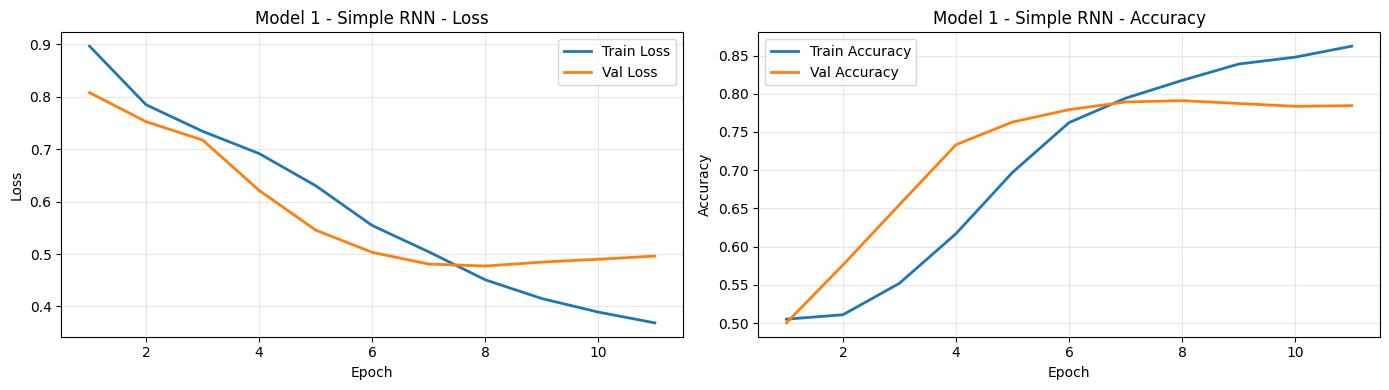

In [13]:
model1_rnn.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_rnn = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr_rnn = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001, verbose=1)

print("Training Model 1: Simple RNN")
t0 = time.time()
history1 = model1_rnn.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop_rnn, reduce_lr_rnn],
    verbose=1
)
time1 = time.time() - t0

print(f"\nTraining time: {time1:.1f}s")
print(f"Final train acc: {history1.history['accuracy'][-1]:.4f}")
print(f"Final val acc: {history1.history['val_accuracy'][-1]:.4f}")

plot_history(history1.history, title='Model 1 - Simple RNN')

**Model 1 Evaluation**

Model 1 - Simple RNN - Test Accuracy: 0.7846

               precision    recall  f1-score   support

Not Sarcastic       0.80      0.79      0.79      2997
    Sarcastic       0.77      0.78      0.77      2727

     accuracy                           0.78      5724
    macro avg       0.78      0.78      0.78      5724
 weighted avg       0.78      0.78      0.78      5724



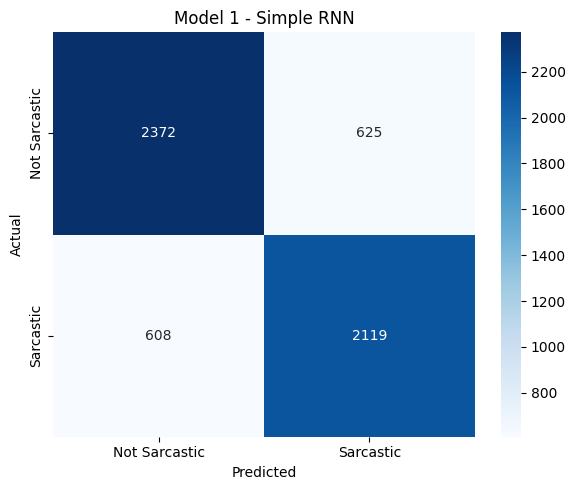


True Not Sarcastic correctly classified: 79.1%
True Sarcastic correctly classified: 77.7%


In [14]:
y_pred1_probs = model1_rnn.predict(X_test_pad, verbose=0)
y_pred1 = (y_pred1_probs > 0.5).astype(int).flatten()

acc1 = accuracy_score(y_test, y_pred1)

print(f"Model 1 - Simple RNN - Test Accuracy: {acc1:.4f}")
print()
print(classification_report(y_test, y_pred1, target_names=['Not Sarcastic', 'Sarcastic']))

plot_confusion_matrix(y_test, y_pred1, title='Model 1 - Simple RNN')

### Model 2: LSTM with Trainable Embedding

In [15]:
def build_lstm(vocab_size, embedding_dim, max_length):
    model = models.Sequential([
        layers.Embedding(vocab_size, embedding_dim, input_length=max_length, mask_zero=True),
        layers.SpatialDropout1D(0.3),
        layers.LSTM(64, return_sequences=True, dropout=0.5, recurrent_dropout=0.5),
        layers.LSTM(32, dropout=0.5, recurrent_dropout=0.5),
        layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model2_lstm = build_lstm(VOCAB_SIZE, EMBEDDING_DIM, MAX_LENGTH)
model2_lstm.build(input_shape=(None, MAX_LENGTH))
model2_lstm.summary()

print(f"\nTotal parameters: {model2_lstm.count_params():,}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 11, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 11, 64)         │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,055,201 (4.03 MB)

 Trainable params: 1,055,201 (4.03 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 1,055,201


**Model 2 Training**

Training Model 2: LSTM
Epoch 1/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.6439 - loss: 0.7603 - val_accuracy: 0.7633 - val_loss: 0.5947 - learning_rate: 5.0000e-04
Epoch 2/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 24s 82ms/step - accuracy: 0.7983 - loss: 0.5156 - val_accuracy: 0.7910 - val_loss: 0.4875 - learning_rate: 5.0000e-04
Epoch 3/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.8491 - loss: 0.4073 - val_accuracy: 0.7901 - val_loss: 0.4844 - learning_rate: 5.0000e-04
Epoch 4/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.8788 - loss: 0.3423 - val_accuracy: 0.7897 - val_loss: 0.5117 - learning_rate: 5.0000e-04
Epoch 5/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8905 - loss: 0.3188
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
287/287 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.8939 - loss: 0.3084 - val_accuracy: 0.7879 - val_loss: 0.5588 - learning_rate: 5.0000e-04
Epoch 6/15
287/287 ━━━━━━━━━━━━━━━━

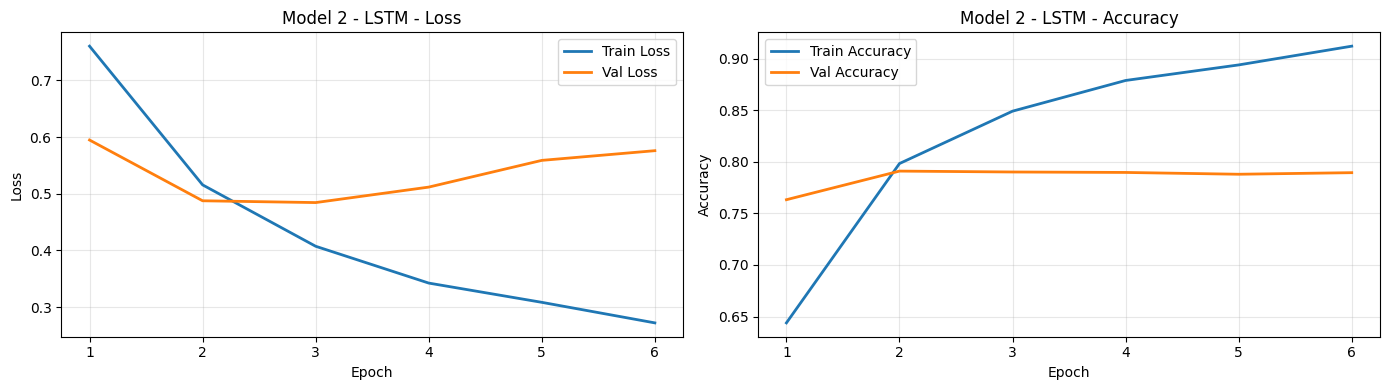

In [16]:
model2_lstm.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_lstm = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr_lstm = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001, verbose=1)

print("Training Model 2: LSTM")
t0 = time.time()
history2 = model2_lstm.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop_lstm, reduce_lr_lstm],
    verbose=1
)
time2 = time.time() - t0

print(f"\nTraining time: {time2:.1f}s")
print(f"Final train acc: {history2.history['accuracy'][-1]:.4f}")
print(f"Final val acc: {history2.history['val_accuracy'][-1]:.4f}")

plot_history(history2.history, title='Model 2 - LSTM')

**Model 2 Evaluation**

Model 2 - LSTM - Test Accuracy: 0.7904

               precision    recall  f1-score   support

Not Sarcastic       0.80      0.79      0.80      2997
    Sarcastic       0.78      0.79      0.78      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724



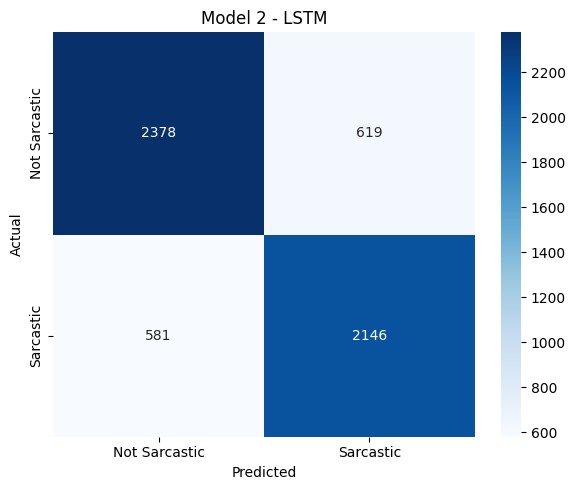


True Not Sarcastic correctly classified: 79.3%
True Sarcastic correctly classified: 78.7%


In [17]:
y_pred2_probs = model2_lstm.predict(X_test_pad, verbose=0)
y_pred2 = (y_pred2_probs > 0.5).astype(int).flatten()

acc2 = accuracy_score(y_test, y_pred2)

print(f"Model 2 - LSTM - Test Accuracy: {acc2:.4f}")
print()
print(classification_report(y_test, y_pred2, target_names=['Not Sarcastic', 'Sarcastic']))

plot_confusion_matrix(y_test, y_pred2, title='Model 2 - LSTM')

### Model 3: LSTM with Pretrained Word2Vec Embeddings

In [18]:
import gensim.downloader as api

print("Loading Word2Vec model (Google News 300d)")
print("This may take a few minutes on first run...")
w2v_model = api.load('word2vec-google-news-300')
EMBEDDING_DIM_W2V = 300

print(f"Word2Vec loaded. Vocab size: {len(w2v_model):,}")

Loading Word2Vec model (Google News 300d)
This may take a few minutes on first run...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec loaded. Vocab size: 3,000,000


In [19]:
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM_W2V))

found = 0
for word, idx in tokenizer.word_index.items():
    if idx < VOCAB_SIZE:
        if word in w2v_model:
            embedding_matrix[idx] = w2v_model[word]
            found += 1

print(f"Words found in Word2Vec: {found} / {VOCAB_SIZE} ({100*found/VOCAB_SIZE:.1f}%)")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Words found in Word2Vec: 9319 / 10000 (93.2%)
Embedding matrix shape: (10000, 300)


In [20]:
def build_lstm_word2vec(vocab_size, embedding_dim, embedding_matrix, max_length):
    model = models.Sequential([
        layers.Embedding(
            vocab_size,
            embedding_dim,
            weights=[embedding_matrix],
            input_length=max_length,
            trainable=False,
            mask_zero=True
        ),
        layers.SpatialDropout1D(0.2),
        layers.LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3),
        layers.LSTM(32, dropout=0.3, recurrent_dropout=0.3),
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model3_w2v = build_lstm_word2vec(VOCAB_SIZE, EMBEDDING_DIM_W2V, embedding_matrix, MAX_LENGTH)
model3_w2v.build(input_shape=(None, MAX_LENGTH))
model3_w2v.summary()

trainable = sum([tf.size(w).numpy() for w in model3_w2v.trainable_weights])
total = model3_w2v.count_params()
print(f"\nTrainable parameters: {trainable:,} / Total: {total:,}")
print(f"Frozen embedding parameters: {total - trainable:,}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 11, 300)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 11, 64)         │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,106,945 (11.85 MB)

 Trainable params: 106,945 (417.75 KB)

 Non-trainable params: 3,000,000 (11.44 MB)


Trainable parameters: 106,945 / Total: 3,106,945
Frozen embedding parameters: 3,000,000


**Model 3 Training**

Training Model 3: LSTM + Word2Vec
Epoch 1/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - accuracy: 0.6702 - loss: 0.6297 - val_accuracy: 0.7111 - val_loss: 0.5752 - learning_rate: 0.0010
Epoch 2/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 29s 100ms/step - accuracy: 0.7178 - loss: 0.5707 - val_accuracy: 0.7181 - val_loss: 0.5661 - learning_rate: 0.0010
Epoch 3/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 29s 101ms/step - accuracy: 0.7309 - loss: 0.5471 - val_accuracy: 0.7353 - val_loss: 0.5352 - learning_rate: 0.0010
Epoch 4/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - accuracy: 0.7437 - loss: 0.5279 - val_accuracy: 0.7497 - val_loss: 0.5154 - learning_rate: 0.0010
Epoch 5/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.7587 - loss: 0.5048 - val_accuracy: 0.7569 - val_loss: 0.5026 - learning_rate: 0.0010
Epoch 6/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.7701 - loss: 0.4866 - val_accuracy: 0.7792 - val_loss: 0.4671 - learning_rate: 0.0010
Epoch 7/20
287/287 ━━━━━━━━━━━━━━━━━━━━

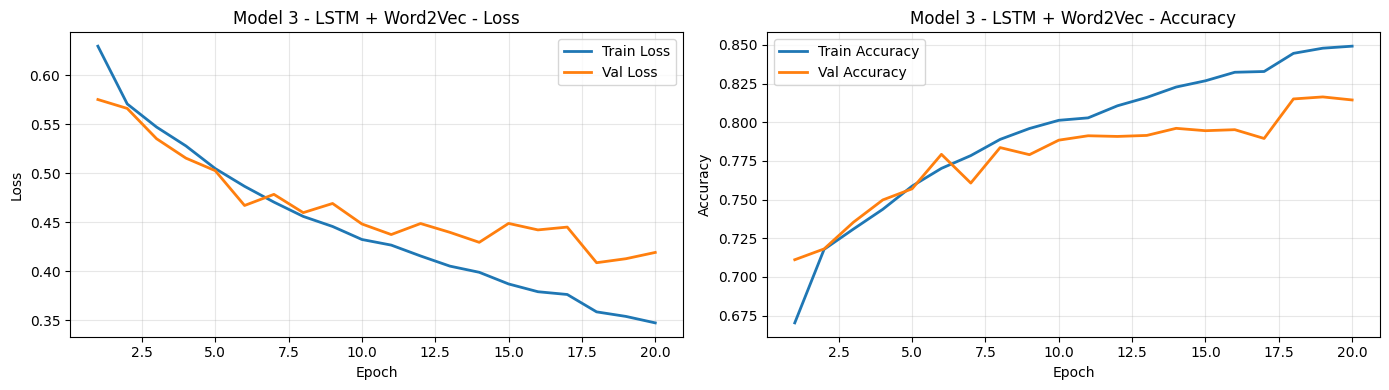

In [21]:
model3_w2v.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_w2v = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr_w2v = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)

print("Training Model 3: LSTM + Word2Vec")
t0 = time.time()
history3 = model3_w2v.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_w2v, reduce_lr_w2v],
    verbose=1
)
time3 = time.time() - t0

print(f"\nTraining time: {time3:.1f}s")
print(f"Final train acc: {history3.history['accuracy'][-1]:.4f}")
print(f"Final val acc: {history3.history['val_accuracy'][-1]:.4f}")

plot_history(history3.history, title='Model 3 - LSTM + Word2Vec')

**Model 3 Evaluation**

Model 3 - LSTM + Word2Vec - Test Accuracy: 0.8103

               precision    recall  f1-score   support

Not Sarcastic       0.83      0.81      0.82      2997
    Sarcastic       0.79      0.81      0.80      2727

     accuracy                           0.81      5724
    macro avg       0.81      0.81      0.81      5724
 weighted avg       0.81      0.81      0.81      5724



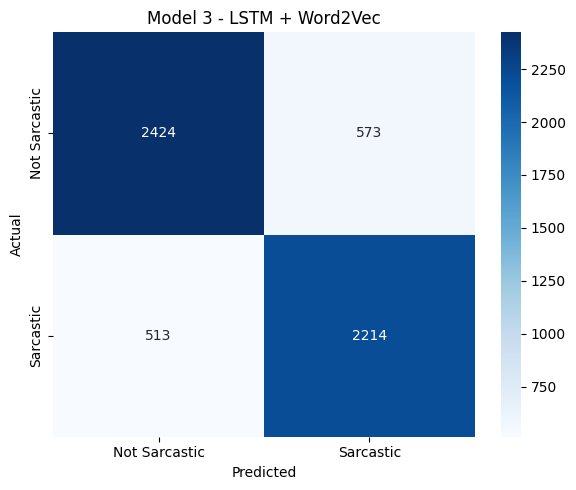


True Not Sarcastic correctly classified: 80.9%
True Sarcastic correctly classified: 81.2%


In [22]:
y_pred3_probs = model3_w2v.predict(X_test_pad, verbose=0)
y_pred3 = (y_pred3_probs > 0.5).astype(int).flatten()

acc3 = accuracy_score(y_test, y_pred3)

print(f"Model 3 - LSTM + Word2Vec - Test Accuracy: {acc3:.4f}")
print()
print(classification_report(y_test, y_pred3, target_names=['Not Sarcastic', 'Sarcastic']))

plot_confusion_matrix(y_test, y_pred3, title='Model 3 - LSTM + Word2Vec')

## Section 3: Comparative Analysis

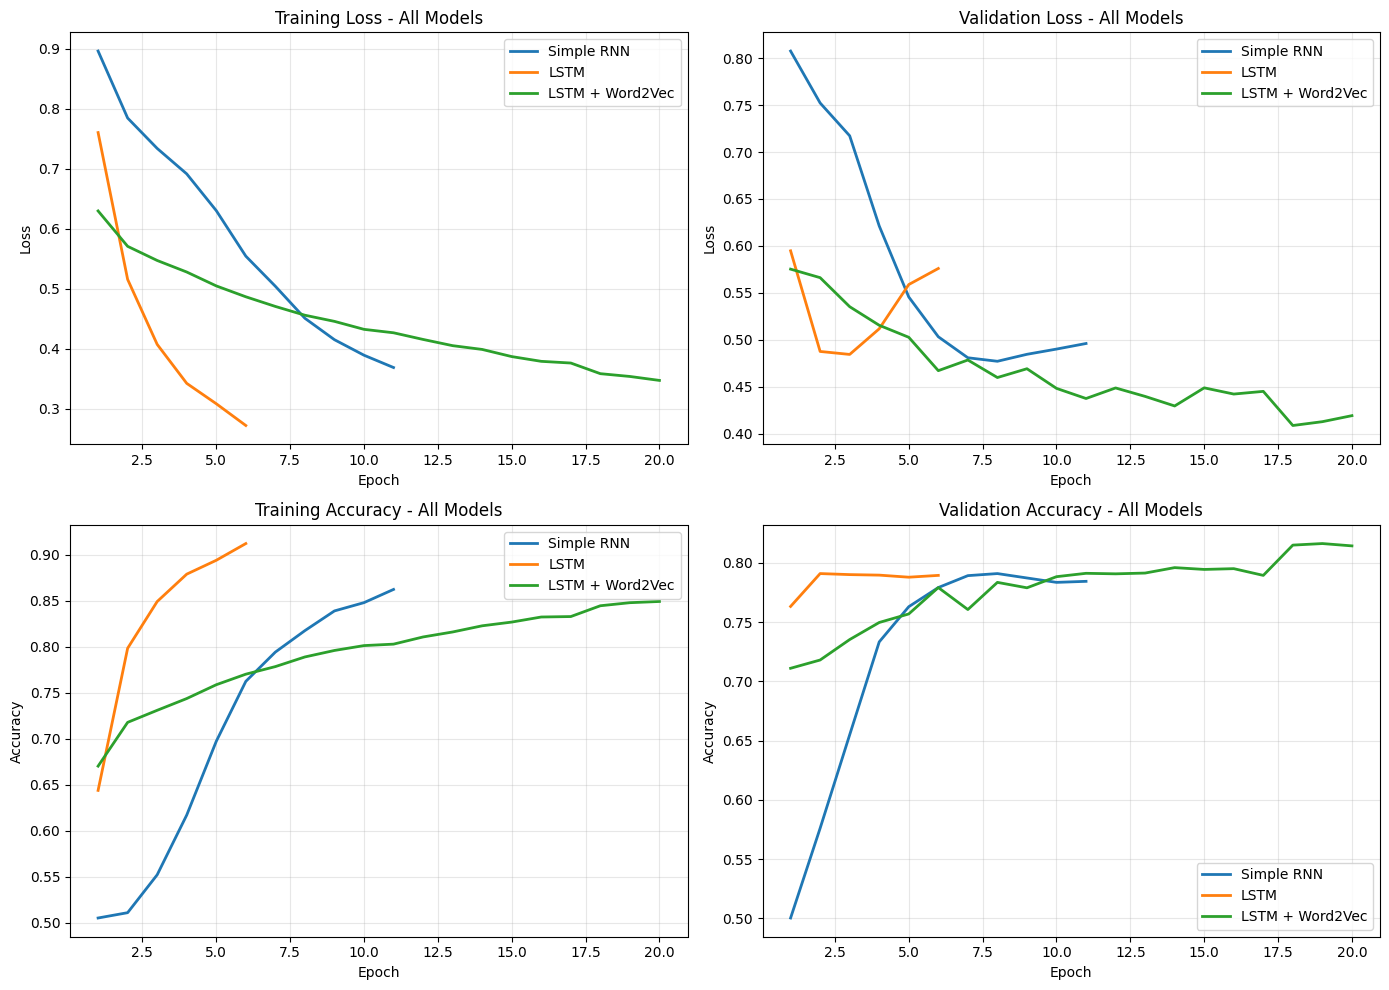

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for hist, label in [(history1.history, 'Simple RNN'), (history2.history, 'LSTM'), (history3.history, 'LSTM + Word2Vec')]:
    epochs = range(1, len(hist['loss']) + 1)
    axes[0, 0].plot(epochs, hist['loss'], label=label, linewidth=2)

axes[0, 0].set_title('Training Loss - All Models')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

for hist, label in [(history1.history, 'Simple RNN'), (history2.history, 'LSTM'), (history3.history, 'LSTM + Word2Vec')]:
    epochs = range(1, len(hist['val_loss']) + 1)
    axes[0, 1].plot(epochs, hist['val_loss'], label=label, linewidth=2)

axes[0, 1].set_title('Validation Loss - All Models')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

for hist, label in [(history1.history, 'Simple RNN'), (history2.history, 'LSTM'), (history3.history, 'LSTM + Word2Vec')]:
    epochs = range(1, len(hist['accuracy']) + 1)
    axes[1, 0].plot(epochs, hist['accuracy'], label=label, linewidth=2)

axes[1, 0].set_title('Training Accuracy - All Models')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

for hist, label in [(history1.history, 'Simple RNN'), (history2.history, 'LSTM'), (history3.history, 'LSTM + Word2Vec')]:
    epochs = range(1, len(hist['val_accuracy']) + 1)
    axes[1, 1].plot(epochs, hist['val_accuracy'], label=label, linewidth=2)

axes[1, 1].set_title('Validation Accuracy - All Models')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
print(f"{'Model':<30}{'Test Acc':<12}{'Train Time (s)':<18}{'Parameters':<15}")
print('-' * 75)
print(f"{'Simple RNN':<30}{acc1:<12.4f}{time1:<18.1f}{model1_rnn.count_params():<15,}")
print(f"{'LSTM':<30}{acc2:<12.4f}{time2:<18.1f}{model2_lstm.count_params():<15,}")
print(f"{'LSTM + Word2Vec':<30}{acc3:<12.4f}{time3:<18.1f}{model3_w2v.count_params():<15,}")

best_acc = max(acc1, acc2, acc3)
best_model = ['Simple RNN', 'LSTM', 'LSTM + Word2Vec'][[acc1, acc2, acc3].index(best_acc)]
print(f"\nBest Model: {best_model} with Test Accuracy: {best_acc:.4f}")

print(f"\nTrain/Val Gap Analysis:")
gap1 = history1.history['accuracy'][-1] - history1.history['val_accuracy'][-1]
gap2 = history2.history['accuracy'][-1] - history2.history['val_accuracy'][-1]
gap3 = history3.history['accuracy'][-1] - history3.history['val_accuracy'][-1]

print(f"Simple RNN: Train={history1.history['accuracy'][-1]:.4f}, Val={history1.history['val_accuracy'][-1]:.4f}, Gap={gap1:.4f}")
print(f"LSTM: Train={history2.history['accuracy'][-1]:.4f}, Val={history2.history['val_accuracy'][-1]:.4f}, Gap={gap2:.4f}")
print(f"LSTM + W2V: Train={history3.history['accuracy'][-1]:.4f}, Val={history3.history['val_accuracy'][-1]:.4f}, Gap={gap3:.4f}")

Model                         Test Acc    Train Time (s)    Parameters     
---------------------------------------------------------------------------
Simple RNN                    0.7846      66.7              1,004,801      
LSTM                          0.7904      135.6             1,055,201      
LSTM + Word2Vec               0.8103      420.7             3,106,945      

Best Model: LSTM + Word2Vec with Test Accuracy: 0.8103

Train/Val Gap Analysis:
Simple RNN: Train=0.8623, Val=0.7845, Gap=0.0778
LSTM: Train=0.9121, Val=0.7895, Gap=0.1226
LSTM + W2V: Train=0.8491, Val=0.8144, Gap=0.0348


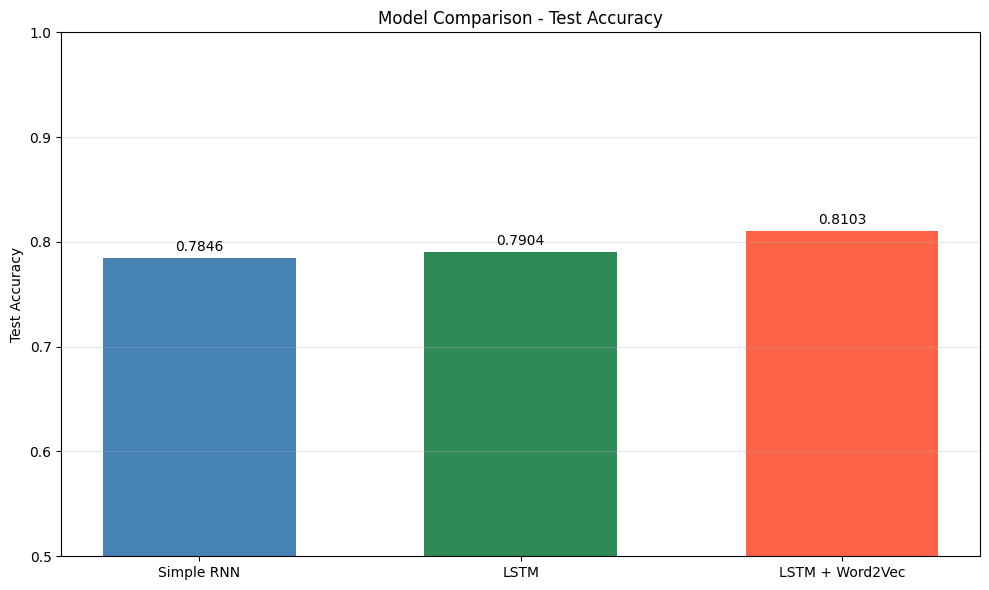

In [31]:
models = ['Simple RNN', 'LSTM', 'LSTM + Word2Vec']
accuracies = [acc1, acc2, acc3]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['steelblue', 'seagreen', 'tomato'], width=0.6)
plt.bar_label(bars, labels=[f'{a:.4f}' for a in accuracies], padding=3)
plt.ylabel('Test Accuracy')
plt.title('Model Comparison - Test Accuracy')
plt.ylim(0.5, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 4: Error Analysis

In [27]:
print("Error Analysis - Model 3 (LSTM + Word2Vec)")

misclassified_idx = np.where(y_test != y_pred3)[0]
total_errors = len(misclassified_idx)

print(f"\nTotal misclassified: {total_errors} / {len(y_test)} ({total_errors/len(y_test)*100:.2f}%)")
print(f"Correctly classified: {len(y_test) - total_errors} / {len(y_test)} ({(len(y_test) - total_errors)/len(y_test)*100:.2f}%)")

fp = sum((y_test == 0) & (y_pred3 == 1))
fn = sum((y_test == 1) & (y_pred3 == 0))

print(f"\nFalse Positives: {fp} ({fp/len(y_test)*100:.2f}%)")
print(f"False Negatives: {fn} ({fn/len(y_test)*100:.2f}%)")

Error Analysis - Model 3 (LSTM + Word2Vec)

Total misclassified: 1086 / 5724 (18.97%)
Correctly classified: 4638 / 5724 (81.03%)

False Positives: 573 (10.01%)
False Negatives: 513 (8.96%)


In [28]:
print("\nMisclassified Examples:")

label_map = {0: 'Not Sarcastic', 1: 'Sarcastic'}

for i, idx in enumerate(misclassified_idx[:3]):
    print(f"\nExample {i+1}:")
    print(f"Headline: {X_test[idx]}")
    print(f"True Label: {label_map[y_test[idx]]}")
    print(f"Predicted: {label_map[y_pred3[idx]]}")


Misclassified Examples:

Example 1:
Headline: rex tillerson call report ouster laughable
True Label: Not Sarcastic
Predicted: Sarcastic

Example 2:
Headline: tom gilbert actor portrays tv regis philbin leave regis kelly show
True Label: Sarcastic
Predicted: Not Sarcastic

Example 3:
Headline: kate middleton suffering morning sickness
True Label: Sarcastic
Predicted: Not Sarcastic


In [32]:
import gradio as gr

def predict_sarcasm(text):
    if not text.strip():
        return "Please enter some text"

    cleaned_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequence, maxlen=MAX_LENGTH, padding='pre', truncating='pre')

    prediction = model3_w2v.predict(padded, verbose=0)[0][0]

    if prediction > 0.5:
        result = f"Sarcastic (confidence: {prediction*100:.1f}%)"
    else:
        result = f"Not Sarcastic (confidence: {(1-prediction)*100:.1f}%)"

    return result

demo = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(label="Enter headline", placeholder="Type a headline here..."),
    outputs=gr.Textbox(label="Prediction"),
    title="Sarcasm Detector",

)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://452b927a76f83d150d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [30]:
!pip install gradio --quiet